# Live Stock Market Exploratory Data Analysis

This project performs exploratory data analysis on live/historical stock market
data collected using the Yahoo Finance API.

### Companies analysed

- Apple
- Microsoft
- NVIDIA
- JPMorgan Chase
- ExxonMobil
- Walmart

### Objectives

The project investigates:

- Stock price movements
- Trading volume
- Daily returns
- Stock volatility
- Cumulative returns
- Correlations between stocks
- Moving averages
- Risk and return characteristics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
!pip install yfinance

In [3]:
stocks = {
    "Apple": "AAPL",
    "Microsoft": "MSFT",
    "NVIDIA": "NVDA",
    "JPMorgan": "JPM",
    "ExxonMobil": "XOM",
    "Walmart": "WMT"
}

tickers = list(stocks.values())

tickers

['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM', 'WMT']

In [4]:
data = yf.download(
    tickers,
    period="2y",
    auto_adjust=False,
    progress=False
)

print("Stock data downloaded successfully!")

Stock data downloaded successfully!


In [5]:
data.head()

Price        Adj Close                                                 \
Ticker            AAPL         JPM        MSFT        NVDA        WMT   
Date                                                                    
2024-09-19  226.971329  201.993042  431.867798  117.554573  76.641136   
2024-09-20  226.306885  202.578415  428.500916  115.689583  77.642860   
2024-09-23  224.591263  202.914307  426.768341  115.948883  78.890091   
2024-09-24  225.483765  203.058304  422.495850  120.546547  79.223991   
2024-09-25  224.492096  201.714752  425.390076  123.179482  79.940910   

Price                        Close                                      ...  \
Ticker             XOM        AAPL         JPM        MSFT        NVDA  ...   
Date                                                                    ...   
2024-09-19  108.798851  228.869995  210.479996  438.690002  117.870003  ...   
2024-09-20  108.114166  228.199997  211.089996  435.269989  116.000000  ...   
2024-09-23  110.074417  226.470001  211.440002  433.510010  116.260002  ...   
2024-09-24  109.783653  227.369995  211.589996  429.170013  120.870003  ...   
2024-09-25  107.645210  226.369995  210.190002  432.109985  123.510002  ...   

Price             Open                                        Volume  \
Ticker            MSFT        NVDA        WMT         XOM       AAPL   
Date                                                                   
2024-09-19  441.230011  117.349998  79.050003  116.160004   66781300   
2024-09-20  437.220001  117.059998  78.230003  115.459999  318679900   
2024-09-23  434.279999  116.550003  79.070000  115.330002   54146000   
2024-09-24  433.000000  116.519997  80.480003  117.839996   43556100   
2024-09-25  429.829987  122.019997  80.889999  116.489998   42308700   

Price                                                          
Ticker           JPM      MSFT       NVDA       WMT       XOM  
Date                                                           
2024-09-19  11635200  21706600  293506400  21525700  12660600  
2024-09-20  20885000  55167100  382462400  39534300  36206200  
2024-09-23   7223500  15128900  206228500  12147300  16066300  
2024-09-24   7323200  17015800  354966800  14651100  11984900  
2024-09-25   8976500  13396400  284692900  14163800  13816000  

[5 rows x 36 columns]

In [6]:
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

Rows: 501
Columns: 36


In [7]:
print("Start date:", data.index.min())
print("End date:", data.index.max())

Start date: 2024-09-19 00:00:00
End date: 2026-09-18 00:00:00


In [8]:
data.columns

MultiIndex([('Adj Close', 'AAPL'),
            ('Adj Close',  'JPM'),
            ('Adj Close', 'MSFT'),
            ('Adj Close', 'NVDA'),
            ('Adj Close',  'WMT'),
            ('Adj Close',  'XOM'),
            (    'Close', 'AAPL'),
            (    'Close',  'JPM'),
            (    'Close', 'MSFT'),
            (    'Close', 'NVDA'),
            (    'Close',  'WMT'),
            (    'Close',  'XOM'),
            (     'High', 'AAPL'),
            (     'High',  'JPM'),
            (     'High', 'MSFT'),
            (     'High', 'NVDA'),
            (     'High',  'WMT'),
            (     'High',  'XOM'),
            (      'Low', 'AAPL'),
            (      'Low',  'JPM'),
            (      'Low', 'MSFT'),
            (      'Low', 'NVDA'),
            (      'Low',  'WMT'),
            (      'Low',  'XOM'),
            (     'Open', 'AAPL'),
            (     'Open',  'JPM'),
            (     'Open', 'MSFT'),
            (     'Open', 'NVDA'),
            (     'O

In [9]:
close_prices = data["Close"].copy()

close_prices.head()

Ticker,AAPL,JPM,MSFT,NVDA,WMT,XOM
Date,,,,,,
2024-09-19,228.869995,210.479996,438.690002,117.870003,78.040001,116.000000
2024-09-20,228.199997,211.089996,435.269989,116.000000,79.059998,115.269997
2024-09-23,226.470001,211.440002,433.510010,116.260002,80.330002,117.360001
2024-09-24,227.369995,211.589996,429.170013,120.870003,80.669998,117.050003
2024-09-25,226.369995,210.190002,432.109985,123.510002,81.400002,114.769997


In [10]:
ticker_to_name = {
    "AAPL": "Apple",
    "MSFT": "Microsoft",
    "NVDA": "NVIDIA",
    "JPM": "JPMorgan",
    "XOM": "ExxonMobil",
    "WMT": "Walmart"
}

close_prices = close_prices.rename(columns=ticker_to_name)

close_prices.head()

Ticker,Apple,JPMorgan,Microsoft,NVIDIA,Walmart,ExxonMobil
Date,,,,,,
2024-09-19,228.869995,210.479996,438.690002,117.870003,78.040001,116.000000
2024-09-20,228.199997,211.089996,435.269989,116.000000,79.059998,115.269997
2024-09-23,226.470001,211.440002,433.510010,116.260002,80.330002,117.360001
2024-09-24,227.369995,211.589996,429.170013,120.870003,80.669998,117.050003
2024-09-25,226.369995,210.190002,432.109985,123.510002,81.400002,114.769997


In [11]:
close_prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 501 entries, 2024-09-19 to 2026-09-18
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Apple       501 non-null    float64
 1   JPMorgan    501 non-null    float64
 2   Microsoft   501 non-null    float64
 3   NVIDIA      501 non-null    float64
 4   Walmart     501 non-null    float64
 5   ExxonMobil  501 non-null    float64
dtypes: float64(6)
memory usage: 27.4 KB


In [12]:
print("Missing values:")

close_prices.isnull().sum()

Missing values:


Ticker
Apple         0
JPMorgan      0
Microsoft     0
NVIDIA        0
Walmart       0
ExxonMobil    0
dtype: int64

In [13]:
print("Duplicate rows:", close_prices.duplicated().sum())

Duplicate rows: 0


In [14]:
close_prices.describe()

Ticker,Apple,JPMorgan,Microsoft,NVIDIA,Walmart,ExxonMobil
count,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000
mean,252.378443,287.420818,445.087505,167.869242,104.434850,125.976228
std,36.294790,38.895677,48.392639,34.119806,13.930617,19.707327
min,172.419998,205.229996,352.829987,94.309998,78.040001,99.930000
25%,226.779999,252.509995,406.350006,137.710007,94.959999,110.650002
50%,248.350006,295.700012,433.309998,177.690002,102.540001,117.220001
75%,273.429993,311.690002,492.019989,191.490005,114.839996,147.279999
max,340.079987,365.179993,542.070007,235.740005,134.199997,171.470001


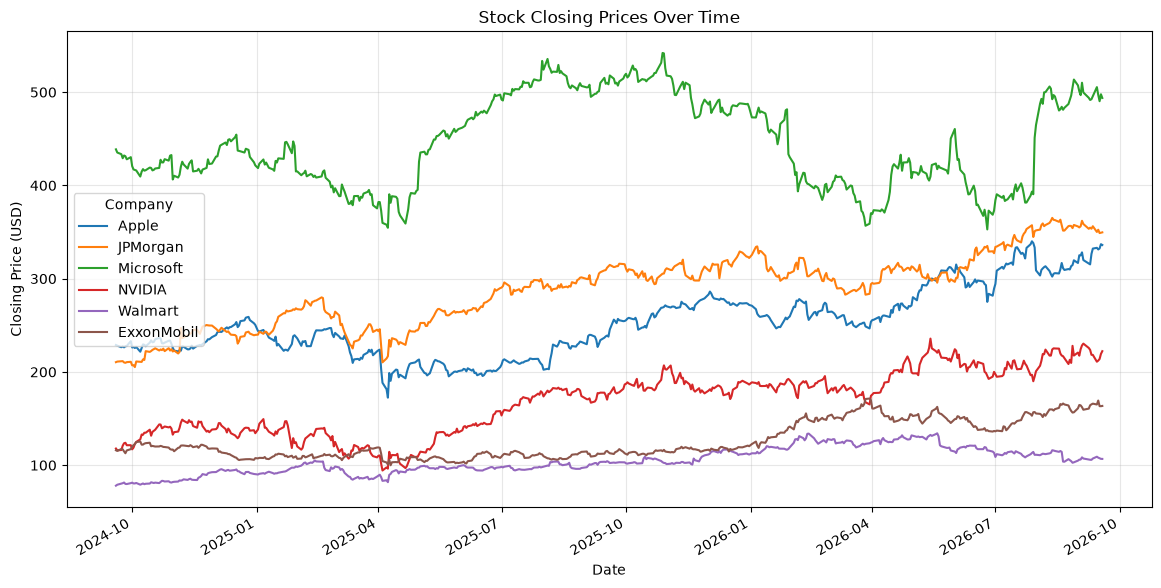

In [15]:
close_prices.plot(figsize=(14, 7))

plt.title("Stock Closing Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend(title="Company")
plt.grid(alpha=0.3)
plt.show()

## Daily Returns Analysis

Stock prices alone cannot be directly compared because each stock has a different
price level. Daily percentage returns allow us to compare the performance and
day-to-day movements of the different stocks on the same scale.

In [16]:
daily_returns = close_prices.pct_change().dropna()

daily_returns.head()

Ticker,Apple,JPMorgan,Microsoft,NVIDIA,Walmart,ExxonMobil
Date,,,,,,
2024-09-20,-0.002927,0.002898,-0.007796,-0.015865,0.013070,-0.006293
2024-09-23,-0.007581,0.001658,-0.004043,0.002241,0.016064,0.018131
2024-09-24,0.003974,0.000709,-0.010011,0.039653,0.004232,-0.002641
2024-09-25,-0.004398,-0.006617,0.006850,0.021842,0.009049,-0.019479
2024-09-26,0.005080,-0.001951,-0.001851,0.004291,-0.018182,-0.017165


In [17]:
daily_returns.describe()

Ticker,Apple,JPMorgan,Microsoft,NVIDIA,Walmart,ExxonMobil
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.000932,0.001136,0.000400,0.001657,0.000751,0.000811
std,0.018149,0.015582,0.018219,0.027847,0.015758,0.015690
min,-0.092456,-0.080502,-0.099931,-0.169682,-0.091514,-0.071956
25%,-0.006759,-0.006257,-0.007953,-0.013605,-0.007815,-0.007507
50%,0.001149,0.001403,0.000390,0.002404,0.001258,0.000933
75%,0.009401,0.009303,0.008458,0.017785,0.008978,0.010027
max,0.153289,0.115445,0.155067,0.187227,0.095488,0.049916


In [18]:
average_daily_returns = daily_returns.mean() * 100

average_daily_returns.sort_values(ascending=False)

Ticker
NVIDIA        0.165705
JPMorgan      0.113648
Apple         0.093236
ExxonMobil    0.081055
Walmart       0.075057
Microsoft     0.040007
dtype: float64

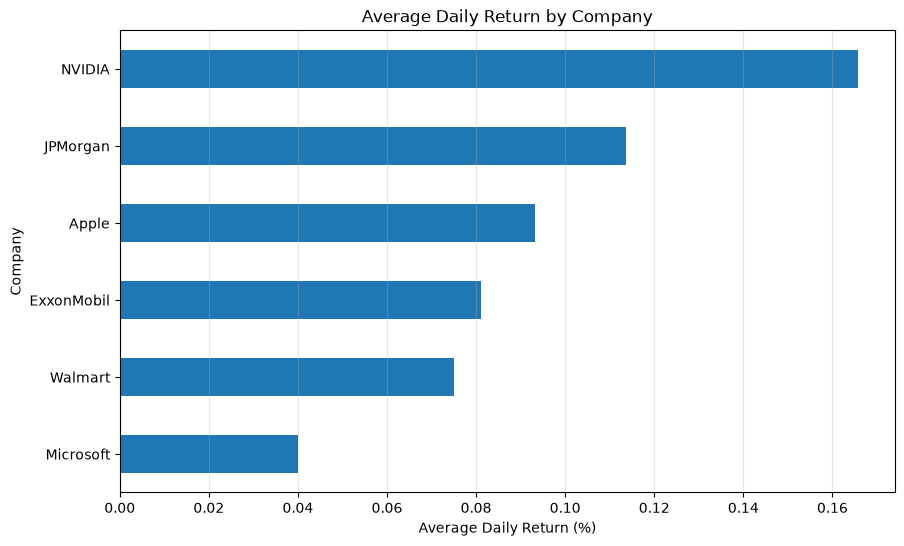

In [19]:
average_daily_returns.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Average Daily Return by Company")
plt.xlabel("Average Daily Return (%)")
plt.ylabel("Company")
plt.grid(axis="x", alpha=0.3)
plt.show()

## Volatility Analysis

Volatility measures how much a stock's returns fluctuate over time.
Higher volatility indicates larger price movements and generally greater
uncertainty in short-term returns.

In [20]:
daily_volatility = daily_returns.std() * 100

daily_volatility.sort_values(ascending=False)

Ticker
NVIDIA        2.784747
Microsoft     1.821898
Apple         1.814906
Walmart       1.575802
ExxonMobil    1.569019
JPMorgan      1.558222
dtype: float64

In [21]:
annualized_volatility = daily_returns.std() * np.sqrt(252) * 100

annualized_volatility.sort_values(ascending=False)

Ticker
NVIDIA        44.206484
Microsoft     28.921737
Apple         28.810735
Walmart       25.015083
ExxonMobil    24.907400
JPMorgan      24.736000
dtype: float64

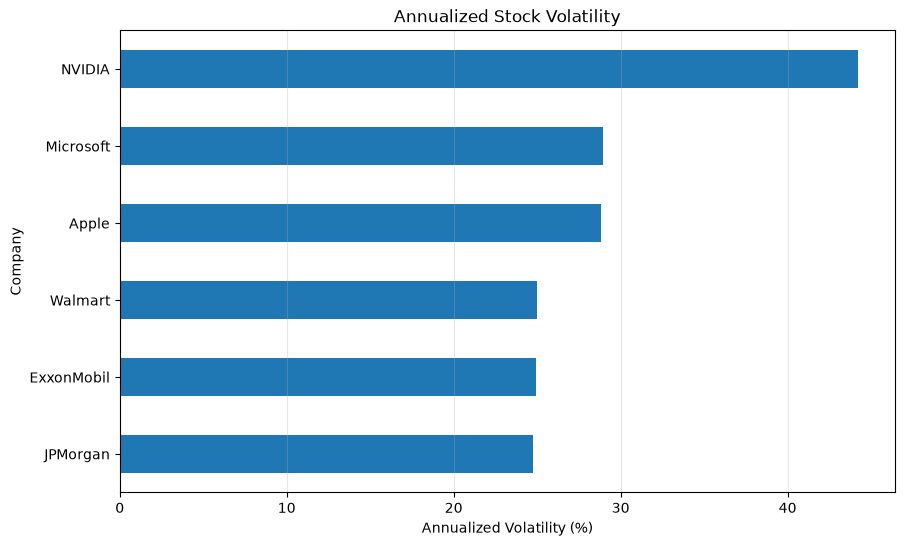

In [22]:
annualized_volatility.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Annualized Stock Volatility")
plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Company")
plt.grid(axis="x", alpha=0.3)
plt.show()

## Cumulative Return Analysis

Cumulative return measures the total percentage change in an investment
over the selected period, assuming returns are compounded over time.
This allows stocks with different share prices to be compared on the
same performance scale.

In [23]:
cumulative_returns = (1 + daily_returns).cumprod() - 1

cumulative_returns.head()

Ticker,Apple,JPMorgan,Microsoft,NVIDIA,Walmart,ExxonMobil
Date,,,,,,
2024-09-20,-0.002927,0.002898,-0.007796,-0.015865,0.013070,-0.006293
2024-09-23,-0.010486,0.004561,-0.011808,-0.013659,0.029344,0.011724
2024-09-24,-0.006554,0.005274,-0.021701,0.025452,0.033701,0.009052
2024-09-25,-0.010923,-0.001378,-0.014999,0.047849,0.043055,-0.010603
2024-09-26,-0.005899,-0.003326,-0.016823,0.052346,0.024090,-0.027586


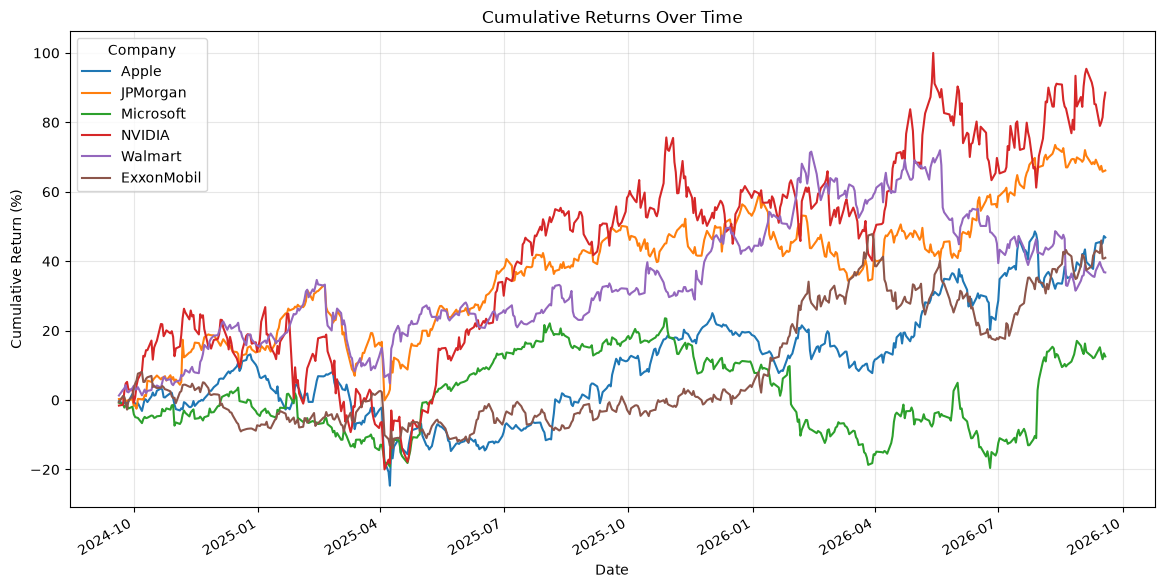

In [24]:
(cumulative_returns * 100).plot(figsize=(14, 7))

plt.title("Cumulative Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.legend(title="Company")
plt.grid(alpha=0.3)
plt.show()

In [25]:
total_returns = cumulative_returns.iloc[-1] * 100

total_returns.sort_values(ascending=False)

Ticker
NVIDIA        88.572155
JPMorgan      66.129808
Apple         46.865038
ExxonMobil    40.982753
Walmart       36.763201
Microsoft     12.557842
Name: 2026-09-18 00:00:00, dtype: float64

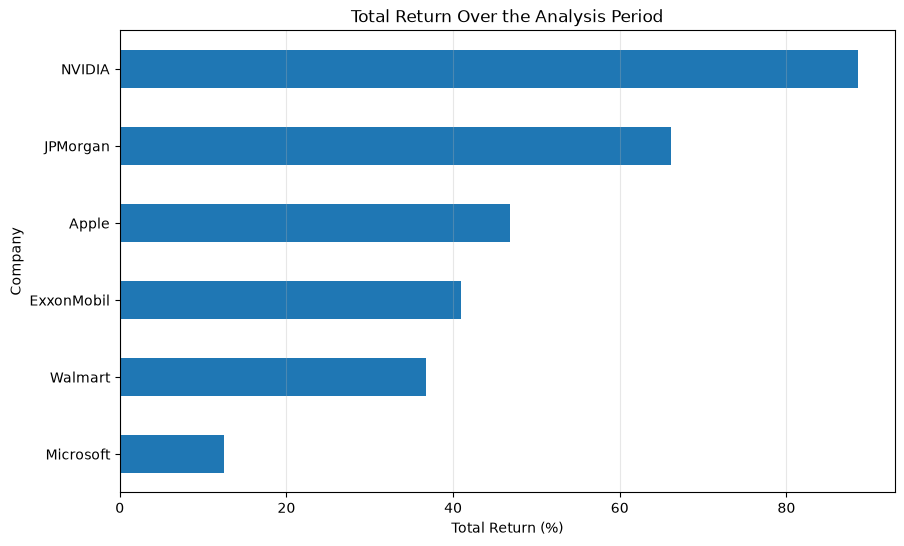

In [26]:
total_returns.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Total Return Over the Analysis Period")
plt.xlabel("Total Return (%)")
plt.ylabel("Company")
plt.grid(axis="x", alpha=0.3)
plt.show()

## Trading Volume Analysis

Trading volume represents the number of shares traded during a given period.
Analyzing volume can help identify periods of unusually high market activity
and compare the trading activity of different stocks.

In [27]:
volume_data = data["Volume"].copy()

volume_data = volume_data.rename(columns=ticker_to_name)

volume_data.head()

Ticker,Apple,JPMorgan,Microsoft,NVIDIA,Walmart,ExxonMobil
Date,,,,,,
2024-09-19,66781300,11635200,21706600,293506400,21525700,12660600
2024-09-20,318679900,20885000,55167100,382462400,39534300,36206200
2024-09-23,54146000,7223500,15128900,206228500,12147300,16066300
2024-09-24,43556100,7323200,17015800,354966800,14651100,11984900
2024-09-25,42308700,8976500,13396400,284692900,14163800,13816000


In [28]:
average_volume = volume_data.mean()

average_volume.sort_values(ascending=False)

Ticker
NVIDIA        1.990780e+08
Apple         5.175819e+07
Microsoft     2.668873e+07
Walmart       2.071763e+07
ExxonMobil    1.684180e+07
JPMorgan      9.256055e+06
dtype: float64

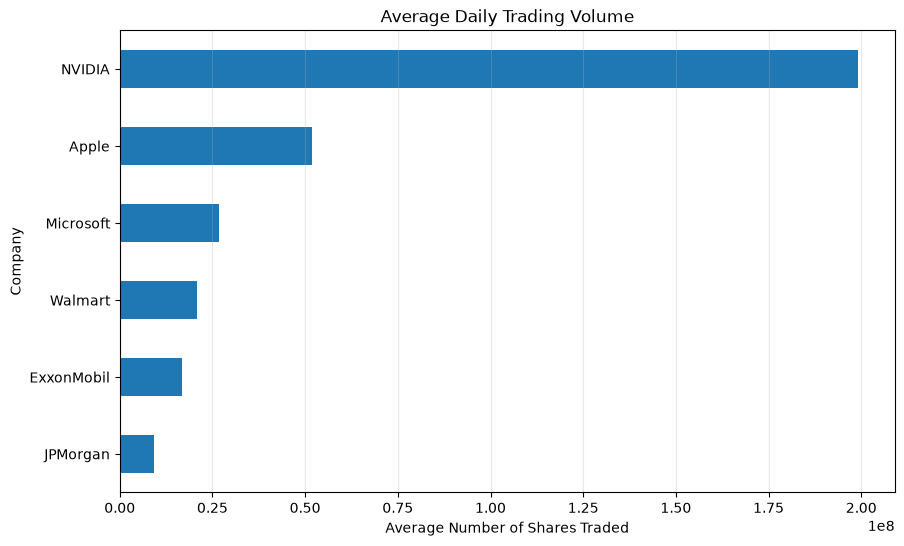

In [29]:
average_volume.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Average Daily Trading Volume")
plt.xlabel("Average Number of Shares Traded")
plt.ylabel("Company")
plt.grid(axis="x", alpha=0.3)
plt.show()

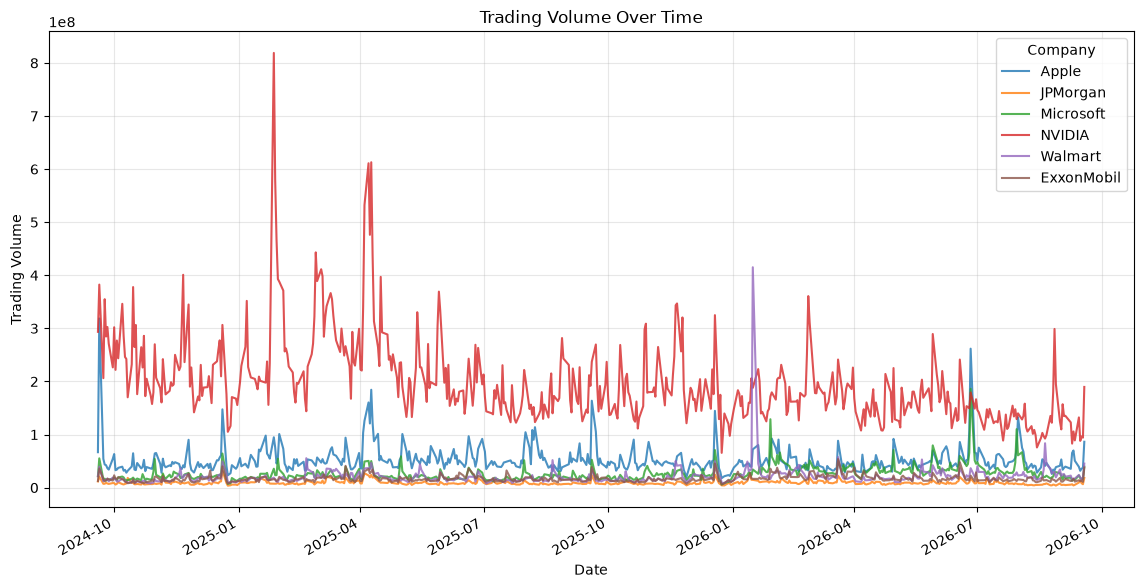

In [30]:
volume_data.plot(
    figsize=(14, 7),
    alpha=0.8
)

plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Trading Volume")
plt.legend(title="Company")
plt.grid(alpha=0.3)
plt.show()

## Distribution of Daily Returns

Examining the distribution of daily returns helps us understand how frequently
stocks experience gains or losses of different magnitudes and whether some
stocks exhibit larger fluctuations than others.

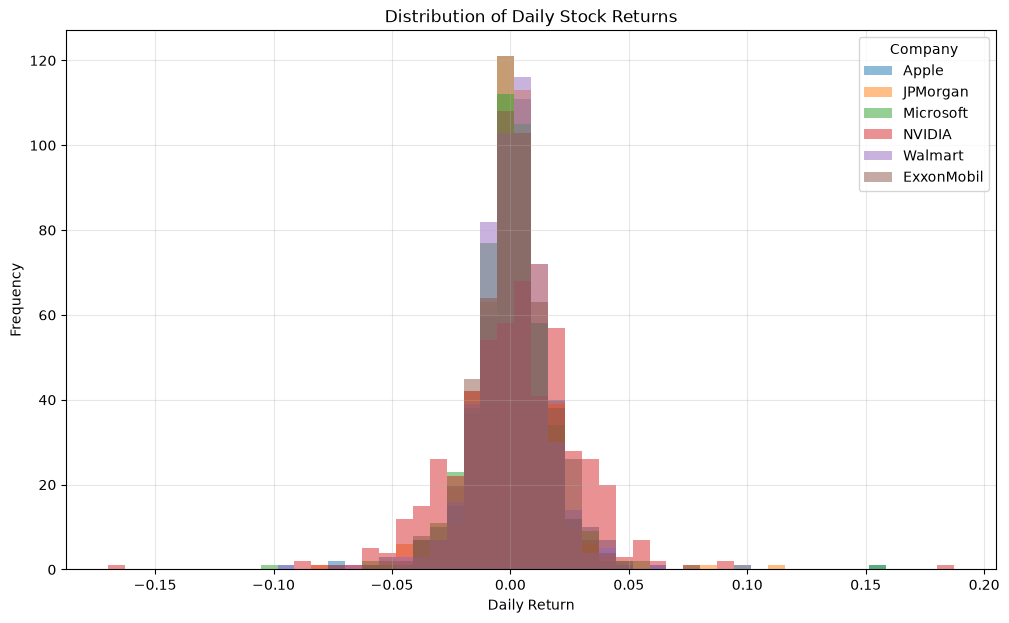

In [31]:
daily_returns.plot(
    kind="hist",
    bins=50,
    alpha=0.5,
    figsize=(12, 7)
)

plt.title("Distribution of Daily Stock Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend(title="Company")
plt.grid(alpha=0.3)
plt.show()

In [32]:
return_skewness = daily_returns.skew()

return_skewness.sort_values()

Ticker
ExxonMobil   -0.443852
Walmart      -0.196473
NVIDIA        0.004052
JPMorgan      0.333498
Apple         0.608522
Microsoft     1.270168
dtype: float64

In [33]:
return_kurtosis = daily_returns.kurtosis()

return_kurtosis.sort_values(ascending=False)

Ticker
Microsoft     14.259596
Apple         12.186338
JPMorgan       9.031606
NVIDIA         6.540281
Walmart        6.437779
ExxonMobil     1.566941
dtype: float64

## Correlation Analysis

Correlation measures the degree to which the daily returns of different stocks
move together.

A correlation close to +1 indicates that two stocks tend to move in the same
direction, while a value closer to 0 indicates a weaker linear relationship.

In [34]:
correlation_matrix = daily_returns.corr()

correlation_matrix

Ticker,Apple,JPMorgan,Microsoft,NVIDIA,Walmart,ExxonMobil
Ticker,,,,,,
Apple,1.000000,0.346874,0.314300,0.305122,0.282203,0.144879
JPMorgan,0.346874,1.000000,0.257844,0.325630,0.215688,0.157288
Microsoft,0.314300,0.257844,1.000000,0.420394,0.073685,-0.012870
NVIDIA,0.305122,0.325630,0.420394,1.000000,0.031901,0.012452
Walmart,0.282203,0.215688,0.073685,0.031901,1.000000,0.083634
ExxonMobil,0.144879,0.157288,-0.012870,0.012452,0.083634,1.000000


In [35]:
import seaborn as sns

In [36]:
import seaborn as sns

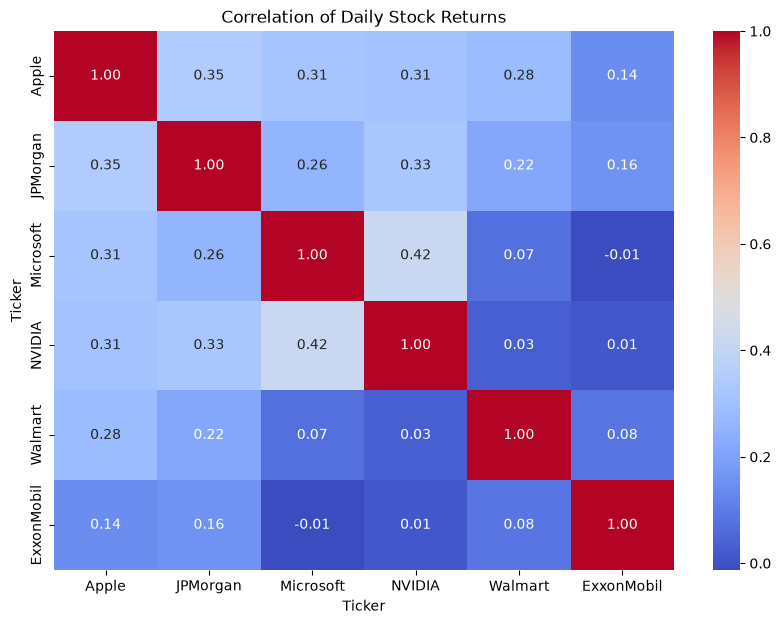

In [37]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation of Daily Stock Returns")
plt.show()

## Moving Average Analysis

Moving averages smooth short-term price fluctuations and make longer-term
trends easier to observe.

This analysis compares the closing price with 20-day and 50-day moving
averages.

In [38]:
nvidia_price = close_prices["NVIDIA"]

nvidia_ma20 = nvidia_price.rolling(window=20).mean()
nvidia_ma50 = nvidia_price.rolling(window=50).mean()

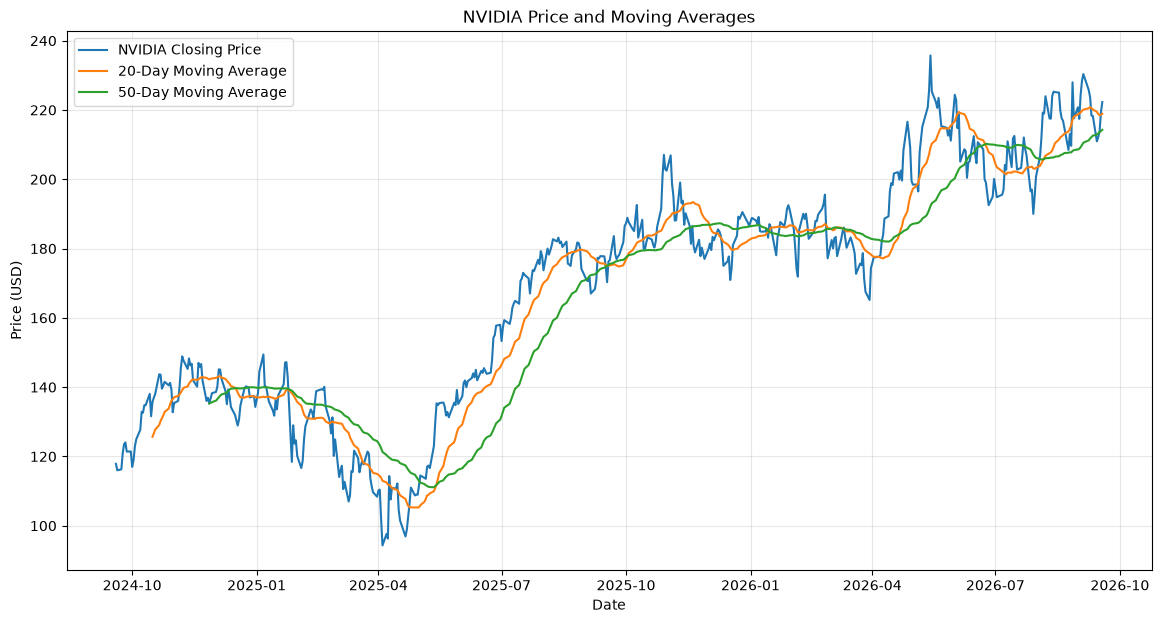

In [39]:
plt.figure(figsize=(14, 7))

plt.plot(
    nvidia_price,
    label="NVIDIA Closing Price"
)

plt.plot(
    nvidia_ma20,
    label="20-Day Moving Average"
)

plt.plot(
    nvidia_ma50,
    label="50-Day Moving Average"
)

plt.title("NVIDIA Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [40]:
print("Latest NVIDIA closing price:")
print(round(nvidia_price.iloc[-1], 2))

print("\nLatest 20-day moving average:")
print(round(nvidia_ma20.iloc[-1], 2))

print("\nLatest 50-day moving average:")
print(round(nvidia_ma50.iloc[-1], 2))

Latest NVIDIA closing price:
222.27

Latest 20-day moving average:
218.88

Latest 50-day moving average:
214.27


## Rolling Volatility Analysis

Rolling volatility shows how the variability of stock returns changes over time.
A 30-day rolling window is used to identify periods when stock price movements
became relatively more or less volatile.

In [41]:
rolling_volatility = daily_returns.rolling(window=30).std() * np.sqrt(252) * 100

rolling_volatility.tail()

Ticker,Apple,JPMorgan,Microsoft,NVIDIA,Walmart,ExxonMobil
Date,,,,,,
2026-09-14,22.429612,14.376535,25.979157,42.689489,32.612756,24.307936
2026-09-15,21.722432,14.496889,22.532187,41.916985,32.690232,25.199732
2026-09-16,21.144770,14.173132,22.709793,41.333341,32.625440,27.431786
2026-09-17,21.386384,14.086857,22.889146,40.778274,32.571217,26.954176
2026-09-18,21.434684,13.924812,21.785457,40.949316,32.571032,26.373481


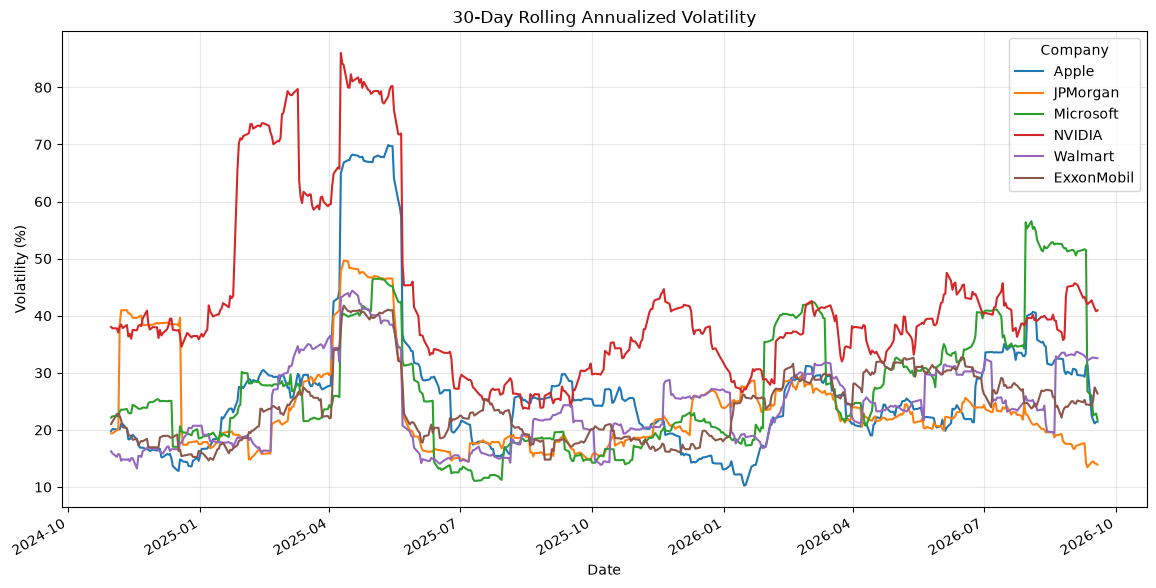

In [42]:
rolling_volatility.plot(figsize=(14, 7))

plt.title("30-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.legend(title="Company")
plt.grid(alpha=0.3)

plt.show()

## Drawdown Analysis

Drawdown measures the percentage decline in a stock's price from its previous
historical peak.

Maximum drawdown represents the largest peak-to-trough decline observed during
the analysis period and provides another way of examining historical downside risk.

In [43]:
running_max = close_prices.cummax()

drawdowns = (close_prices / running_max) - 1

drawdowns.tail()

Ticker,Apple,JPMorgan,Microsoft,NVIDIA,Walmart,ExxonMobil
Date,,,,,,
2026-09-14,-0.020583,-0.041213,-0.067630,-0.105116,-0.187183,-0.037266
2026-09-15,-0.025700,-0.034750,-0.082923,-0.099983,-0.194560,-0.012539
2026-09-16,-0.022553,-0.044526,-0.095504,-0.092644,-0.198957,-0.047530
2026-09-17,-0.009057,-0.043458,-0.081761,-0.069568,-0.204247,-0.047822
2026-09-18,-0.011615,-0.042472,-0.089084,-0.057139,-0.204694,-0.046247


In [44]:
max_drawdowns = drawdowns.min() * 100

max_drawdowns.sort_values()

Ticker
NVIDIA       -36.886835
Microsoft    -34.910624
Apple        -33.433710
JPMorgan     -24.886591
Walmart      -23.524590
ExxonMobil   -20.650845
dtype: float64

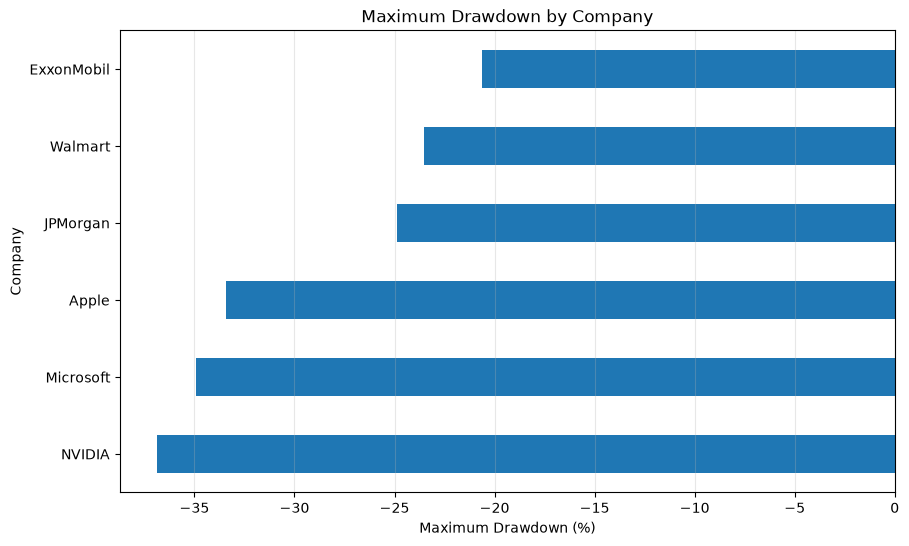

In [45]:
max_drawdowns.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Maximum Drawdown by Company")
plt.xlabel("Maximum Drawdown (%)")
plt.ylabel("Company")
plt.grid(axis="x", alpha=0.3)

plt.show()

## Best and Worst Trading Days

This section identifies the largest positive and negative daily returns observed
for each stock during the analysis period.

In [46]:
best_days = daily_returns.max() * 100
worst_days = daily_returns.min() * 100

best_worst = pd.DataFrame({
    "Best Daily Return (%)": best_days,
    "Worst Daily Return (%)": worst_days
})

best_worst

,Best Daily Return (%),Worst Daily Return (%)
Ticker,,
Apple,15.328853,-9.245610
JPMorgan,11.544535,-8.050200
Microsoft,15.506733,-9.993149
NVIDIA,18.722740,-16.968166
Walmart,9.548842,-9.151362
ExxonMobil,4.991571,-7.195592


## Risk vs Return Analysis

This analysis compares each stock's annualized return with its annualized
volatility.

Return represents historical performance, while volatility represents the
variability of daily returns during the analysis period.

In [47]:
annualized_return = daily_returns.mean() * 252 * 100

risk_return = pd.DataFrame({
    "Annualized Return (%)": annualized_return,
    "Annualized Volatility (%)": annualized_volatility
})

risk_return

,Annualized Return (%),Annualized Volatility (%)
Ticker,,
Apple,23.495477,28.810735
JPMorgan,28.639320,24.736000
Microsoft,10.081781,28.921737
NVIDIA,41.757761,44.206484
Walmart,18.914244,25.015083
ExxonMobil,20.425746,24.907400


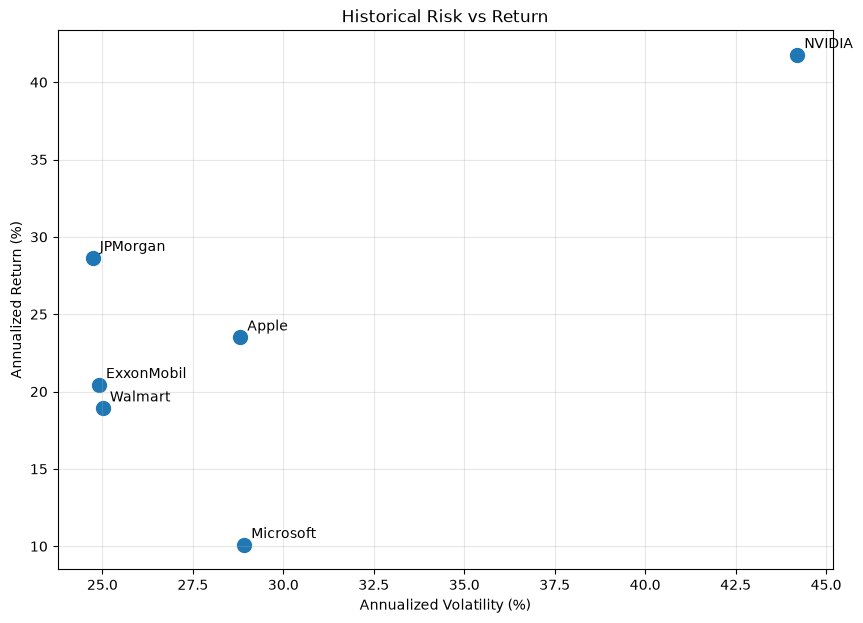

In [48]:
plt.figure(figsize=(10, 7))

plt.scatter(
    risk_return["Annualized Volatility (%)"],
    risk_return["Annualized Return (%)"],
    s=100
)

for company in risk_return.index:
    plt.annotate(
        company,
        (
            risk_return.loc[company, "Annualized Volatility (%)"],
            risk_return.loc[company, "Annualized Return (%)"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Historical Risk vs Return")
plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Return (%)")
plt.grid(alpha=0.3)

plt.show()

## Summary of EDA Findings

The following table combines the major performance and risk metrics calculated
during the exploratory analysis.

In [49]:
summary = pd.DataFrame({
    "Total Return (%)": total_returns,
    "Avg Daily Return (%)": average_daily_returns,
    "Annualized Return (%)": annualized_return,
    "Annualized Volatility (%)": annualized_volatility,
    "Maximum Drawdown (%)": max_drawdowns,
    "Best Day (%)": best_days,
    "Worst Day (%)": worst_days
})

summary = summary.round(2)

summary

,Total Return (%),Avg Daily Return (%),Annualized Return (%),Annualized Volatility (%),Maximum Drawdown (%),Best Day (%),Worst Day (%)
Ticker,,,,,,,
Apple,46.87,0.09,23.50,28.81,-33.43,15.33,-9.25
JPMorgan,66.13,0.11,28.64,24.74,-24.89,11.54,-8.05
Microsoft,12.56,0.04,10.08,28.92,-34.91,15.51,-9.99
NVIDIA,88.57,0.17,41.76,44.21,-36.89,18.72,-16.97
Walmart,36.76,0.08,18.91,25.02,-23.52,9.55,-9.15
ExxonMobil,40.98,0.08,20.43,24.91,-20.65,4.99,-7.20


In [51]:
print("Highest total return:")
print(total_returns.idxmax(), "-", round(total_returns.max(), 2), "%")

print("\nHighest annualized volatility:")
print(annualized_volatility.idxmax(), "-", round(annualized_volatility.max(), 2), "%")

print("\nLowest annualized volatility:")
print(annualized_volatility.idxmin(), "-", round(annualized_volatility.min(), 2), "%")

print("\nLargest maximum drawdown:")
print(
    max_drawdowns.idxmin(),
    "-",
    round(abs(max_drawdowns.min()), 2),
    "% decline"
)

print("\nHighest correlation pair:")

corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

print(
    corr_pairs.index[0],
    "-",
    round(corr_pairs.iloc[0], 2)
)

Highest total return:
NVIDIA - 88.57 %

Highest annualized volatility:
NVIDIA - 44.21 %

Lowest annualized volatility:
JPMorgan - 24.74 %

Largest maximum drawdown:
NVIDIA - 36.89 % decline

Highest correlation pair:
('Microsoft', 'NVIDIA') - 0.42


## Key Findings

The exploratory analysis revealed several notable patterns across the six stocks
during the selected analysis period.

### 1. NVIDIA recorded the highest total return

NVIDIA produced the highest cumulative return at approximately **88.57%**.
It also had the highest average daily return and annualized return among the
stocks analysed.

However, this higher historical return was accompanied by substantially
higher volatility.

### 2. NVIDIA also experienced the highest volatility

NVIDIA had an annualized volatility of approximately **44.21%**, considerably
higher than the other stocks in the analysis.

It also experienced the largest maximum drawdown at approximately **-36.89%**,
showing that its stronger historical performance was accompanied by larger
price fluctuations and deeper declines from previous peaks.

### 3. JPMorgan showed strong returns with comparatively lower volatility

JPMorgan generated a total return of approximately **66.13%** while its
annualized volatility was approximately **24.74%**.

This demonstrates that stocks with relatively strong returns during the period
did not necessarily have the highest volatility.

### 4. Microsoft recorded the lowest total return

Microsoft produced a total return of approximately **12.56%**, the lowest among
the six stocks analysed.

Its annualized volatility was approximately **28.92%**, showing that lower
historical return did not necessarily correspond to lower volatility.

### 5. ExxonMobil experienced the smallest maximum drawdown

ExxonMobil's maximum drawdown was approximately **-20.65%**, the smallest
peak-to-trough decline among the stocks in this dataset.

Its total return over the analysis period was approximately **40.98%**.

### 6. Daily stock returns were not perfectly correlated

The correlation analysis showed varying relationships between the stocks.

Microsoft and NVIDIA had the strongest positive correlation among the pairs
observed, at approximately **0.42**.

Microsoft and ExxonMobil had a correlation close to zero at approximately
**-0.01**, indicating very little linear relationship between their daily
returns during the selected period.

## Limitations

This analysis has several limitations:

- The analysis covers only approximately two years of historical market data.
- Only six publicly traded companies were included.
- Historical returns and volatility do not predict future market performance.
- The analysis does not account for dividends, transaction costs, taxes,
  inflation, or investor-specific circumstances.
- Correlation measures linear relationships and does not imply causation.
- Market behaviour can change over time, meaning historical relationships
  may not remain stable.
- The dataset is retrieved from Yahoo Finance through the yfinance library,
  so results depend on the availability and accuracy of the underlying data.

## Conclusion

This project used Python to perform exploratory data analysis on historical
stock market data for six companies from different industries.

The analysis examined closing prices, daily returns, cumulative returns,
trading volume, volatility, return distributions, correlations, moving
averages, rolling volatility, drawdowns, and extreme daily price movements.

The results demonstrate that return and risk characteristics varied
substantially across the selected companies during the analysis period.
For example, NVIDIA recorded the highest total return but also exhibited
the highest volatility and largest maximum drawdown.

The project also demonstrates how financial market data can be collected,
cleaned, transformed, analysed, and visualized entirely within a Jupyter
Notebook using Python.

The findings describe historical behaviour within the selected dataset and
should not be interpreted as predictions of future stock performance or
investment recommendations.

In [52]:
summary.to_csv("stock_eda_summary.csv")

print("Summary exported successfully!")

Summary exported successfully!
